In [ ]:
# === repo-root bootstrap (added during the experiments/ reorganization) ===
# Locate the repository root (the directory containing `core/`), switch the
# working directory there, and put it on sys.path. This lets the notebook
# import `core`/`execution`/`analysis` and resolve every `shared_data/...`
# path regardless of which directory the notebook was launched from.
import os, sys
_root = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(_root, "core")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
assert os.path.isdir(os.path.join(_root, "core")), "repo root (with core/) not found"
os.chdir(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)
print("Repo root:", _root)

# Unrolled QPA Qubit Scaling

Measures how the **qubit count** of the unrolled QPA circuit scales with `N` (number of registers) for several trial depths `T`.

- Strategy: `unrolled` (longest-path / all-Schur-tests-pass branch)
- `K = 2` (qubits per data register)
- `T = 1, 2, 3`
- `N = 3, 5, 7, ..., 23`
- `no_reset = True` (fresh ancillas per trial — same setup as `transpile_scaling_unrolled_T*.ipynb`)

Qubit count is structural (independent of backend / transpilation), so we just construct the circuit and read `qc.num_qubits`. Results are written to `scaling_results/qubit_scaling.json` and `.csv`.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Make the project-root `core/` package importable
# (this notebook lives in unrolled_experiment/).
_PROJECT_ROOT = Path.cwd()
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

from core.circuit_factory import CircuitFactory

In [2]:
# --- Experiment parameters ---
N_LIST = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23]
T_LIST = [1, 2, 3]
K = 2
NO_RESET = True

# --- Persistence paths ---
RESULTS_DIR = Path("shared_data/experiment_results/unrolled_scaling")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
JSON_PATH = RESULTS_DIR / "qubit_scaling.json"
CSV_PATH  = RESULTS_DIR / "qubit_scaling.csv"

print(f"N values : {N_LIST}")
print(f"T values : {T_LIST}  (K={K}, no_reset={NO_RESET})")
print(f"Results  : {JSON_PATH}")

N values : [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23]
T values : [1, 2, 3]  (K=2, no_reset=True)
Results  : scaling_results/qubit_scaling.json


## Build circuits and count qubits

Build the unrolled circuit set via `CircuitFactory.create_strategy("unrolled", ...)` and take **path 0** (the all-Schur-tests-pass / longest-path branch — same convention as the depth-scaling notebooks). Read `num_qubits` directly off that circuit.

We also break down the count into:
- **data qubits**: `N * K`
- **ancilla qubits**: `(N // 2) * T` (with `no_reset=True`)

In [3]:
def build_longest_path_circuit(k, t, n, no_reset):
    strategy = CircuitFactory.create_strategy("unrolled", k, t, n, no_reset=no_reset)
    strategy.set_noise_strategy(None)
    paths = strategy.build(0.0)
    return paths[0]['circuit']

results = []
for t in T_LIST:
    for n in N_LIST:
        qc = build_longest_path_circuit(K, t, n, NO_RESET)
        data_qubits    = n * K
        ancilla_qubits = (n // 2) * t if NO_RESET else (n // 2)
        results.append({
            "t": t,
            "n": n,
            "k": K,
            "no_reset": NO_RESET,
            "num_qubits": qc.num_qubits,
            "data_qubits": data_qubits,
            "ancilla_qubits": ancilla_qubits,
        })
        print(f"T={t}  N={n:>2}  ->  {qc.num_qubits} qubits  "
              f"(data={data_qubits}, ancilla={ancilla_qubits})")

with open(JSON_PATH, "w") as f:
    json.dump(results, f, indent=2)
pd.DataFrame(results).to_csv(CSV_PATH, index=False)
print(f"\nSaved {len(results)} entries to {JSON_PATH}")

T=1  N= 3  ->  7 qubits  (data=6, ancilla=1)
T=1  N= 5  ->  12 qubits  (data=10, ancilla=2)
T=1  N= 7  ->  17 qubits  (data=14, ancilla=3)
T=1  N= 9  ->  22 qubits  (data=18, ancilla=4)
T=1  N=11  ->  27 qubits  (data=22, ancilla=5)
T=1  N=13  ->  32 qubits  (data=26, ancilla=6)
T=1  N=15  ->  37 qubits  (data=30, ancilla=7)
T=1  N=17  ->  42 qubits  (data=34, ancilla=8)
T=1  N=19  ->  47 qubits  (data=38, ancilla=9)
T=1  N=21  ->  52 qubits  (data=42, ancilla=10)
T=1  N=23  ->  57 qubits  (data=46, ancilla=11)
T=2  N= 3  ->  8 qubits  (data=6, ancilla=2)
T=2  N= 5  ->  14 qubits  (data=10, ancilla=4)
T=2  N= 7  ->  20 qubits  (data=14, ancilla=6)
T=2  N= 9  ->  26 qubits  (data=18, ancilla=8)
T=2  N=11  ->  32 qubits  (data=22, ancilla=10)
T=2  N=13  ->  38 qubits  (data=26, ancilla=12)
T=2  N=15  ->  44 qubits  (data=30, ancilla=14)
T=2  N=17  ->  50 qubits  (data=34, ancilla=16)
T=2  N=19  ->  56 qubits  (data=38, ancilla=18)
T=2  N=21  ->  62 qubits  (data=42, ancilla=20)
T=2  N=23

## Summary table

Pivoted by `T` so each column is a trial depth and each row is a value of `N`.

In [4]:
with open(JSON_PATH) as f:
    disk_results = json.load(f)

df = pd.DataFrame(disk_results)
pivot = df.pivot(index="n", columns="t", values="num_qubits")
pivot.columns = [f"T={t}" for t in pivot.columns]
pivot.index.name = "N"
pivot

,T=1,T=2,T=3
N,,,
3,7,8,9
5,12,14,16
7,17,20,23
9,22,26,30
11,27,32,37
13,32,38,44
15,37,44,51
17,42,50,58
19,47,56,65


## Scaling plot

Total qubit count vs `N`, one line per `T`.

Saved plot to scaling_results/qubit_scaling.png


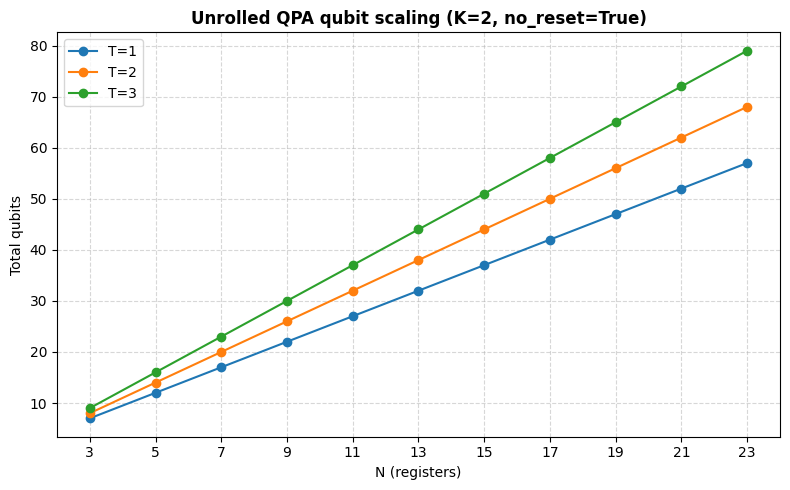

In [5]:
with open(JSON_PATH) as f:
    disk_results = json.load(f)
df = pd.DataFrame(disk_results)

colors = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c"}

fig, ax = plt.subplots(figsize=(8, 5))
for t in T_LIST:
    sub = df[df["t"] == t].sort_values("n")
    ax.plot(sub["n"], sub["num_qubits"], marker="o", color=colors.get(t),
            label=f"T={t}")

ax.set_xlabel("N (registers)")
ax.set_ylabel("Total qubits")
ax.set_title(f"Unrolled QPA qubit scaling (K={K}, no_reset={NO_RESET})",
             fontweight="bold")
ax.set_xticks(N_LIST)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

plot_path = RESULTS_DIR / "qubit_scaling.png"
plt.tight_layout()
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
print(f"Saved plot to {plot_path}")
plt.show()